# EDA 02 - Road Closures

**Output**: `data/processed/road_closures_clean.parquet`, `data/processed/unplanned_road_closures.parquet`, `data/processed/planned_road_closures.parquet`

This notebook prepares DATEX II closure records before any exploratory analysis. The workflow is raw load, timestamp parsing, feature preparation, duplicate removal, Parquet save and then EDA on the cleaned closure records.

## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_02", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
os.makedirs("./sample_data/processed", exist_ok=True)
%matplotlib inline

## 1. Load and Inspect Raw Data

In [2]:
from datetime import datetime, timezone
from src.data_loader import load_road_closures

START = datetime(2026, 4, 10, 0, 0, 0, tzinfo=timezone.utc)
END   = datetime(2026, 4, 30, 23, 59, 59, tzinfo=timezone.utc)

road_df = load_road_closures(START, END)
print(f"Shape: {road_df.shape}")
print(f"Columns: {list(road_df.columns)}")
display(road_df.head())

Using 43 local files within the time window.
Shape: (1776, 14)
Columns: ['situation_id', 'record_id', 'start_time', 'end_time', 'validity_status', 'cause_type', 'source', 'road_name', 'lanes_closed', 'closure_lat', 'closure_lon', 'poslist', 'ingestion_time', 'closure_type']


,situation_id,record_id,start_time,end_time,validity_status,cause_type,source,road_name,lanes_closed,closure_lat,closure_lon,poslist,ingestion_time,closure_type
0,481398,1-1770230430-d6ff48ca-8971-4f31-831f-272231753b8a,2026-04-11T19:00:00Z,2026-04-12T05:00:00Z,planned,roadMaintenance,roadworks,M11,2,52.241032,0.056728,['52.237974 0.062705 52.237644 0.063174 52.237...,2026-04-11 05:09:20.728518,planned
1,481398,1-1770230430-ee17da45-7781-4cee-85b8-1958b86f1b72,2026-04-11T19:00:00Z,2026-04-12T05:00:00Z,planned,roadMaintenance,roadworks,A14,1,52.240029,0.059073,['52.240826 0.057497 52.240366 0.058604 52.239...,2026-04-11 05:09:20.728567,planned
2,481398,1-1770230430-acff749b-b497-4d6f-a60f-01677b02af5c,2026-04-09T19:00:00Z,2026-04-10T05:00:00Z,planned,roadMaintenance,roadworks,A14,2,52.260536,0.016397,['52.257609 0.023547 52.257608 0.023549 52.257...,2026-04-11 05:09:20.728631,planned
3,481533,1-1770819974-8fa8f569-45d0-4710-a6df-39f3d37e1c3d,2026-04-09T19:00:00Z,2026-04-10T05:00:00Z,planned,roadMaintenance,roadworks,M1,3,52.847611,-1.298524,['52.855638 -1.299951 52.855692 -1.299979 52.8...,2026-04-11 05:09:20.728723,planned
4,470844,1-1770730368-f293b6be-d3b5-410b-9fc8-9761a531e558,2026-04-10T08:00:00Z,2026-04-10T14:00:00Z,planned,roadMaintenance,roadworks,A36,1,51.075089,-1.787852,['51.075752 -1.790037 51.075673 -1.78978 51.07...,2026-04-11 05:09:20.728744,planned


## 2. Data preprocessing, deduplication and Parquet save

The planned closure feed is polled repeatedly, so the same active closure can appear in more than one daily file. A closure is treated as the same event when `situation_id`, `record_id`, `start_time` and `end_time` match. The earliest ingestion record is retained because repeated rows only differ by ingestion metadata.

`record_id` is included because one road situation can contain more than one affected segment. Using only `situation_id` would collapse valid multi-segment closures.

In [3]:
road_raw_df = road_df.copy()

# Convert closure times once before duration and duplicate checks.
for col, new_col in [("start_time", "start_time_dt"), ("end_time", "end_time_dt")]:
    road_raw_df[new_col] = (
        pd.to_datetime(road_raw_df[col].astype(str).str.slice(0, 19), errors="coerce")
        .dt.tz_localize("UTC")
    )

# Clip long closures to the analysis window
road_raw_df["duration_hours"] = (
    road_raw_df["end_time_dt"] - road_raw_df["start_time_dt"]
).dt.total_seconds() / 3600
road_raw_df["effective_start_time"] = road_raw_df["start_time_dt"].clip(lower=START)
road_raw_df["effective_end_time"] = road_raw_df["end_time_dt"].clip(upper=END)
road_raw_df["effective_duration_hours"] = (
    road_raw_df["effective_end_time"] - road_raw_df["effective_start_time"]
).dt.total_seconds() / 3600

In [4]:
# Classify roads by importance based on their names.
ROAD_CLASS_WEIGHT = {"M": 3, "A": 2, "B": 1}

def classify_road(name):
    """Return a simple road importance weight from the road name."""
    if pd.isna(name):
        return ROAD_CLASS_WEIGHT["B"]
    name = str(name).strip().upper()
    if name.startswith("M") or "(M)" in name:
        return ROAD_CLASS_WEIGHT["M"]
    if name.startswith("A"):
        return ROAD_CLASS_WEIGHT["A"]
    return ROAD_CLASS_WEIGHT["B"]

road_raw_df["road_class"] = road_raw_df["road_name"].apply(classify_road)
road_raw_df["closure_severity"] = road_raw_df["road_class"] * road_raw_df["effective_duration_hours"]


In [5]:
# Daily re-polls are removed by event identity, not by file name.
dedup_key = [c for c in ["situation_id", "record_id", "start_time", "end_time"] if c in road_raw_df.columns]
sort_cols = [c for c in ["ingestion_time", "source_file"] if c in road_raw_df.columns]
before_dedup = len(road_raw_df)
road_clean = (
    road_raw_df
    .sort_values(sort_cols if sort_cols else dedup_key)
    .drop_duplicates(subset=dedup_key, keep="first")
    .copy()
)
dedup_removed = before_dedup - len(road_clean)

# Coordinates and parsed times are required for later station proximity joins.
required_cols = ["closure_lat", "closure_lon", "start_time_dt", "end_time_dt"]
before_required = len(road_clean)
road_clean = road_clean.dropna(subset=required_cols).copy()
required_removed = before_required - len(road_clean)

print(f"Initial road closures: {len(road_df):,} rows")
print(f"Removed by deduplication: {dedup_removed:,} rows")

Initial road closures: 1,776 rows
Removed by deduplication: 303 rows


In [6]:
# Convert IDs to string for better handling in joins.
for col in ["situation_id", "record_id"]:
    if col in road_clean.columns:
        road_clean[col] = road_clean[col].astype("string")

road_clean.to_parquet("./data/processed/road_closures_clean.parquet", index=False)
road_clean.query("closure_type == 'unplanned'").to_parquet("./data/processed/unplanned_road_closures.parquet", index=False)
road_clean.query("closure_type == 'planned'").to_parquet("./data/processed/planned_road_closures.parquet", index=False)

# Use the cleaned dataframe for all EDA cells below.
road_clean_df = road_clean.copy()

print(f"Raw rows loaded:             {len(road_raw_df):,}")
print(f"Duplicate rows removed:      {dedup_removed:,}")
print(f"Rows removed after QA checks: {required_removed:,}")
print(f"Clean rows saved:            {len(road_clean_df):,}")
print(f"Deduplication key:           {dedup_key}")

Raw rows loaded:             1,776
Duplicate rows removed:      303
Rows removed after QA checks: 0
Clean rows saved:            1,473
Deduplication key:           ['situation_id', 'record_id', 'start_time', 'end_time']


In [7]:
road_clean_df["road_name"].unique()

<ArrowStringArray>
[    'M11',     'A14',      'M1',     'A36',      'M5',     'A47',   'A1(M)',
     'M60',     'M65',    'A174',     'M67',     'A34',      'A1',     'A19',
     'A31',     'M32',     'M25',      'M6',     'M69',    'A453',    'M606',
     'M62',     'A50',      'A3',     'M40',     'A52',     'A30',     'M53',
     'M56',    'A414',     'M66',     'M61', 'A627(M)',     'A46',     'A66',
    'A417',    'M602',     'M18',    'A282',   'A3(M)',   'A1033',      'M4',
     'M23',     'M20',    'M621',     'M42',     'M27',    'M271',     'A11',
    'A303',    'A428',     'A21',    'A249',    'A616',     'M50',     'A38',
    'A696',     'A55',     'A45',     'M45',     'A69',      'M2',      'M3',
    'A595',     'A20',     'A40',    'A483',   'A4280',    'A590',   'A1053',
     'A43',     'A57',     'A27',     'M57',      'A2',   'A5127',  'A38(M)',
 'M6 TOLL',     'M48',    'A556',     'M55',     'A42', 'A308(M)',     'A12',
     'A64',     'A56']
Length: 86, dtype: str

In [8]:
# Full dtypes and non-null counts
road_clean_df.info()

<class 'pandas.DataFrame'>
Index: 1473 entries, 0 to 1775
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   situation_id              1473 non-null   string             
 1   record_id                 1473 non-null   string             
 2   start_time                1473 non-null   str                
 3   end_time                  1473 non-null   str                
 4   validity_status           1473 non-null   str                
 5   cause_type                1473 non-null   str                
 6   source                    1473 non-null   str                
 7   road_name                 1473 non-null   str                
 8   lanes_closed              1473 non-null   int64              
 9   closure_lat               1473 non-null   float64            
 10  closure_lon               1473 non-null   float64            
 11  poslist                   1473 no

In [9]:
# Numeric summary
road_clean_df.describe().round(2)

,lanes_closed,closure_lat,closure_lon,duration_hours,effective_duration_hours,road_class,closure_severity
count,1473.00,1473.00,1473.00,1473.00,1473.00,1473.00,1473.00
mean,0.42,52.48,-1.22,361.39,27.78,2.86,70.52
std,0.89,0.96,0.97,2076.92,106.02,0.34,274.44
min,0.00,50.24,-5.26,0.25,0.01,2.00,0.04
25%,0.00,51.58,-2.08,0.25,0.25,3.00,0.75
50%,0.00,52.40,-1.29,0.25,0.25,3.00,0.75
75%,0.00,53.43,-0.47,6.83,4.00,3.00,10.00
max,5.00,55.07,1.72,25810.10,504.00,3.00,1512.00


## 3. Missing value audit

This audit is run on the cleaned closure table. It confirms that the fields needed for spatial matching and duration calculations are available before the remaining EDA summaries are produced.

In [10]:
# Count and percentage of missing values per column
missing = pd.DataFrame({
    "missing_count": road_clean_df.isna().sum(),
    "missing_pct": (road_clean_df.isna().sum() / len(road_df) * 100).round(2)
}).sort_values("missing_pct", ascending=False)

print(missing.to_string())

                          missing_count  missing_pct
situation_id                          0          0.0
record_id                             0          0.0
start_time                            0          0.0
end_time                              0          0.0
validity_status                       0          0.0
cause_type                            0          0.0
source                                0          0.0
road_name                             0          0.0
lanes_closed                          0          0.0
closure_lat                           0          0.0
closure_lon                           0          0.0
poslist                               0          0.0
ingestion_time                        0          0.0
closure_type                          0          0.0
start_time_dt                         0          0.0
end_time_dt                           0          0.0
duration_hours                        0          0.0
effective_start_time                  0       

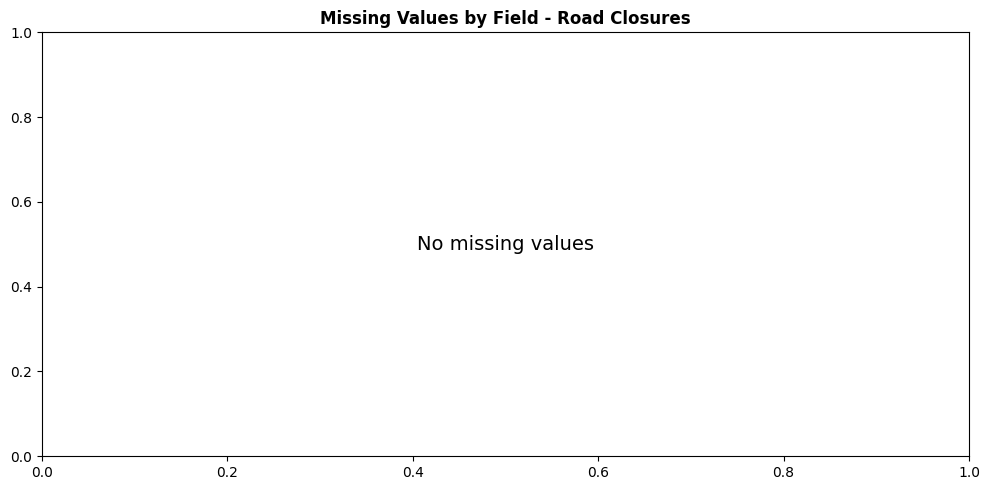

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
missing_nonzero = missing[missing["missing_pct"] > 0]

if len(missing_nonzero) > 0:
    ax.barh(missing_nonzero.index, missing_nonzero["missing_pct"],
            color="tomato", edgecolor="black")
    ax.set_xlabel("Missing (%)")
    for i, v in enumerate(missing_nonzero["missing_pct"]):
        ax.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)
else:
    ax.text(0.5, 0.5, "No missing values", ha="center", va="center",
            transform=ax.transAxes, fontsize=14)

ax.set_title("Missing Values by Field - Road Closures", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_02/missing_values.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Duration analysis

Raw duration covers the full declared closure window. Effective duration clips this to the analysis period, so a long-running closure does not receive an inflated weight simply because it began before the study window or ended after it.

In [12]:
print("Raw duration (hours):")
print(road_clean_df["duration_hours"].describe().round(2))
print()
print("Effective duration (hours):")
print(road_clean_df["effective_duration_hours"].describe().round(2))
print()
print(f"Closures <= 2h:   {(road_clean_df['duration_hours'] <= 2).sum():,}")
print(f"Closures 2-12h:   {((road_clean_df['duration_hours'] > 2) & (road_clean_df['duration_hours'] <= 12)).sum():,}")
print(f"Closures 12-24h:  {((road_clean_df['duration_hours'] > 12) & (road_clean_df['duration_hours'] <= 24)).sum():,}")
print(f"Closures > 24h:   {(road_clean_df['duration_hours'] > 24).sum():,}")

Raw duration (hours):
count     1473.00
mean       361.39
std       2076.92
min          0.25
25%          0.25
50%          0.25
75%          6.83
max      25810.10
Name: duration_hours, dtype: float64

Effective duration (hours):
count    1473.00
mean       27.78
std       106.02
min         0.01
25%         0.25
50%         0.25
75%         4.00
max       504.00
Name: effective_duration_hours, dtype: float64

Closures <= 2h:   1,084
Closures 2-12h:   281
Closures 12-24h:  0
Closures > 24h:   108


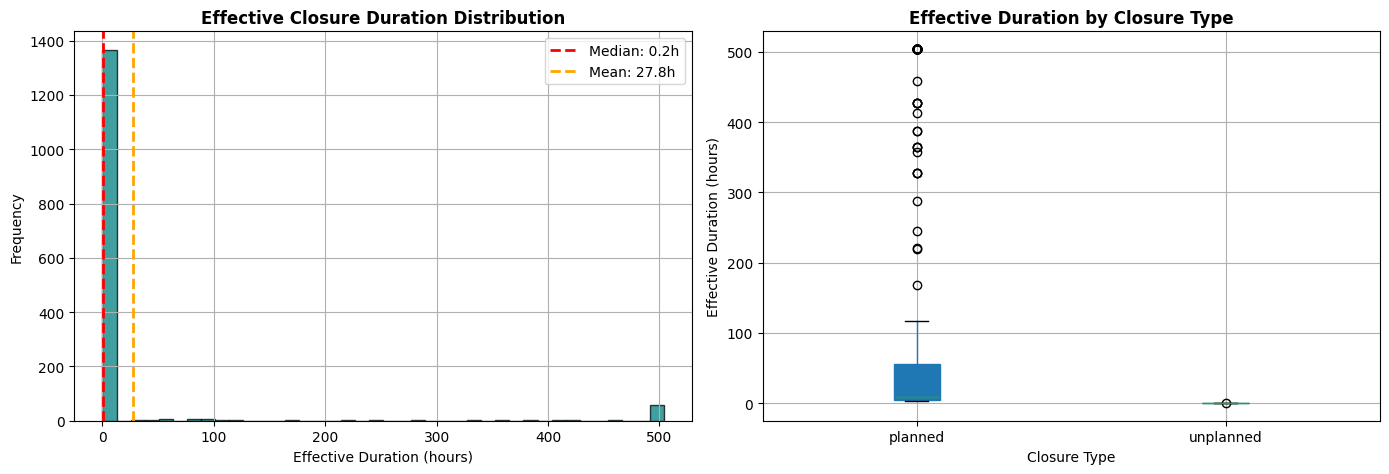

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

road_clean_df["effective_duration_hours"].hist(
    bins=40, ax=axes[0], edgecolor="black", alpha=0.75, color="teal"
)
axes[0].axvline(road_clean_df["effective_duration_hours"].median(), color="red",
                linestyle="--", lw=2,
                label=f"Median: {road_clean_df['effective_duration_hours'].median():.1f}h")
axes[0].axvline(road_clean_df["effective_duration_hours"].mean(), color="orange",
                linestyle="--", lw=2,
                label=f"Mean: {road_clean_df['effective_duration_hours'].mean():.1f}h")
axes[0].set_xlabel("Effective Duration (hours)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Effective Closure Duration Distribution", fontweight="bold")
axes[0].legend()

road_clean_df.boxplot(column="effective_duration_hours", by="closure_type",
                ax=axes[1], patch_artist=True)
axes[1].set_title("Effective Duration by Closure Type", fontweight="bold")
axes[1].set_xlabel("Closure Type")
axes[1].set_ylabel("Effective Duration (hours)")
plt.suptitle("")

plt.tight_layout()
plt.savefig("figures/eda_02/duration_analysis.png", dpi=200, bbox_inches="tight")
plt.show()

In [14]:
print("Road Closures Earlier Start Time:", road_clean_df["start_time_dt"].min())
print("Road Closures Latest End Time:", road_clean_df["end_time_dt"].max())

Road Closures Earlier Start Time: 2024-12-31 06:00:00+00:00
Road Closures Latest End Time: 2028-03-31 22:59:00+00:00


## 5. Closure Type and Validity Status

The `closure_type` field is derived from the filename at load time (planned vs unplanned). The `validity_status` field reflects the operational state of the closure at ingestion time.

In [15]:
# Closure type counts
print("=== Closure Type ===")
ct = road_clean_df["closure_type"].value_counts()
print(ct.to_string())
print()

# Validity status counts
print("=== Validity Status ===")
vs = road_clean_df["validity_status"].value_counts()
print(vs.to_string())
print()
# Cross-tabulation: closure type vs validity status
print("=== Cross-tabulation: Closure Type vs Validity Status ===")
ct_vs = pd.crosstab(road_clean_df["closure_type"], road_clean_df["validity_status"],
                    margins=True, margins_name="Total")
print(ct_vs.to_string())

=== Closure Type ===
closure_type
unplanned    1084
planned       389

=== Validity Status ===
validity_status
suspended    1112
planned       264
active         97

=== Cross-tabulation: Closure Type vs Validity Status ===
validity_status  active  planned  suspended  Total
closure_type                                      
planned              96      264         29    389
unplanned             1        0       1083   1084
Total                97      264       1112   1473


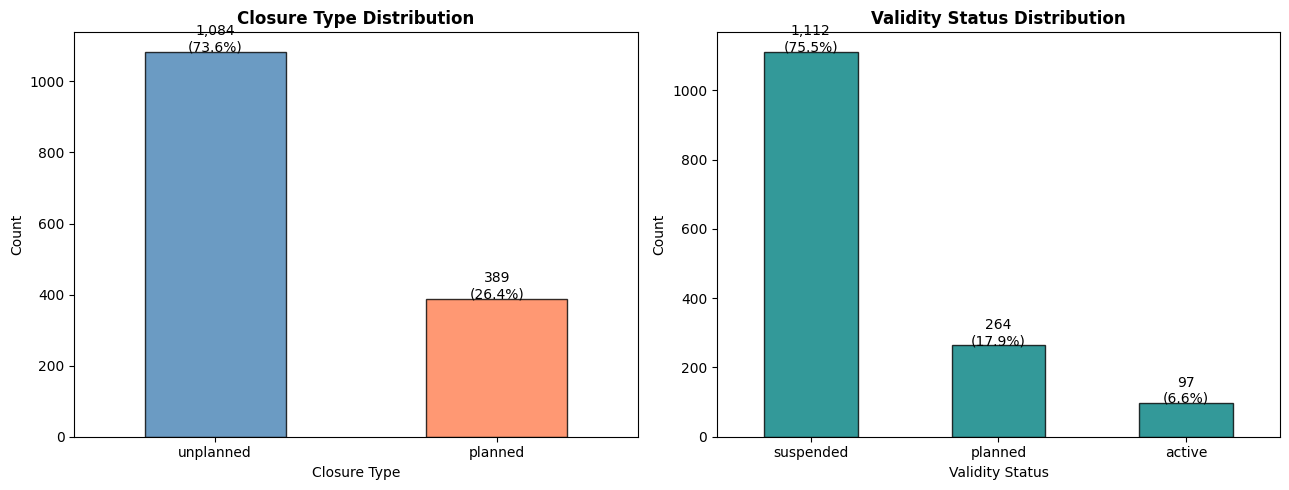

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Closure type
ct.plot(kind="bar", ax=axes[0], color=["steelblue", "coral"],
        edgecolor="black", alpha=0.8)
axes[0].set_title("Closure Type Distribution", fontweight="bold")
axes[0].set_xlabel("Closure Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(ct.values):
    axes[0].text(i, v + 1, f"{v:,}\n({v/len(road_clean_df)*100:.1f}%)",
                 ha="center", fontsize=10)

# Validity status
vs.plot(kind="bar", ax=axes[1], color="teal", edgecolor="black", alpha=0.8)
axes[1].set_title("Validity Status Distribution", fontweight="bold")
axes[1].set_xlabel("Validity Status")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(vs.values):
    axes[1].text(i, v + 0.5, f"{v:,}\n({v/len(road_clean_df)*100:.1f}%)",
                 ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("figures/eda_02/closure_type_validity.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Cause Type and Source Breakdown

`cause_type` indicates the reason for the closure (e.g. roadMaintenance). `source` indicates the reporting system. Understanding these distributions informs which closure types are most relevant to rail disruption.

In [17]:
print("=== Cause Type ===")
cause = road_clean_df["cause_type"].value_counts()
print(cause.to_string())
print()

print("=== Source ===")
source = road_clean_df["source"].value_counts()
print(source.to_string())

# Cause type by closure type (planned vs unplanned)
print()
print("=== Cause Type vs Closure Type ===")
cause_by_type = pd.crosstab(road_clean_df["cause_type"], road_clean_df["closure_type"])
print(cause_by_type.to_string())

=== Cause Type ===
cause_type
roadOrCarriagewayOrLaneManagement    1084
roadMaintenance                       298
constructionWork                       76
authorityOperation                     15

=== Source ===
source
Signs and Signals    1084
roadworks             389

=== Cause Type vs Closure Type ===
closure_type                       planned  unplanned
cause_type                                           
authorityOperation                      15          0
constructionWork                        76          0
roadMaintenance                        298          0
roadOrCarriagewayOrLaneManagement        0       1084


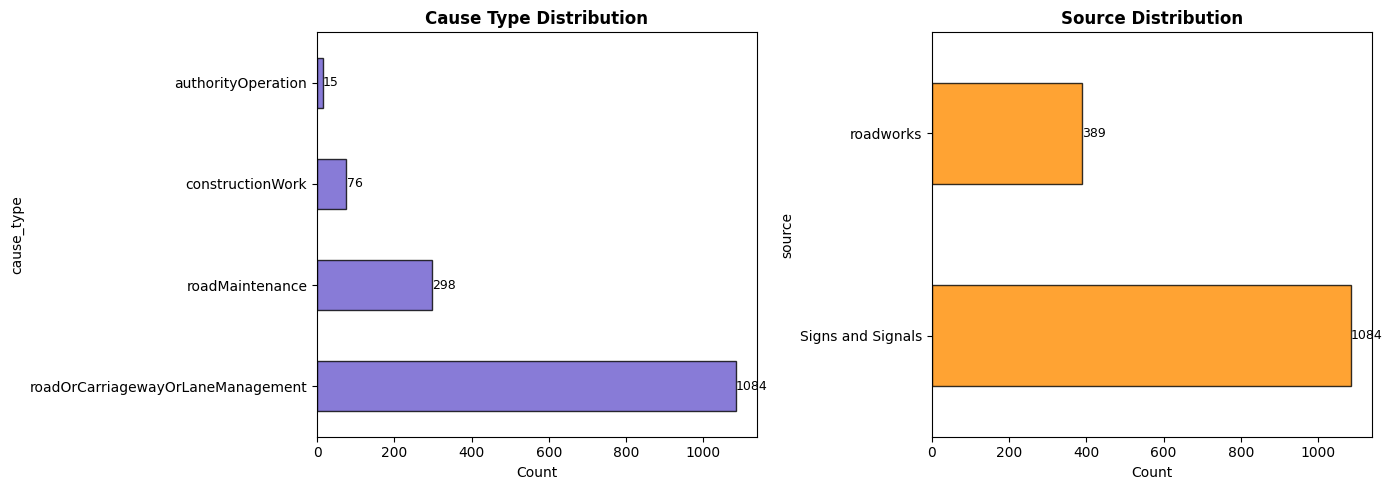

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cause.plot(kind="barh", ax=axes[0], color="slateblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Cause Type Distribution", fontweight="bold")
axes[0].set_xlabel("Count")
for i, v in enumerate(cause.values):
    axes[0].text(v + 0.3, i, str(v), va="center", fontsize=9)

source.plot(kind="barh", ax=axes[1], color="darkorange", edgecolor="black", alpha=0.8)
axes[1].set_title("Source Distribution", fontweight="bold")
axes[1].set_xlabel("Count")
for i, v in enumerate(source.values):
    axes[1].text(v + 0.3, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("figures/eda_02/cause_source.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Road Class Classification and Severity Weight

Each closure is assigned a road class weight: motorways (M) score 3, A-roads score 2, B-roads score 1. `closure_severity` is the product of this weight and `effective_duration_hours`, giving a single scalar that captures both road importance and how long the closure was active. This feature is used as `total_closure_severity` in the station-day aggregation in EDA 05.

In [19]:
ROAD_CLASS_WEIGHT = {"M": 3, "A": 2, "B": 1}

def classify_road(name):
    """Return road class weight based on road name prefix.
    Motorways (M or A(M)) -> 3, A-roads -> 2, all others -> 1.
    """
    if pd.isna(name):
        return ROAD_CLASS_WEIGHT["B"]
    name = name.strip().upper()
    if name.startswith("M") or "(M)" in name:
        return ROAD_CLASS_WEIGHT["M"]
    elif name.startswith("A"):
        return ROAD_CLASS_WEIGHT["A"]
    else:
        return ROAD_CLASS_WEIGHT["B"]

road_clean_df["road_class"]       = road_clean_df["road_name"].apply(classify_road)
road_clean_df["closure_severity"] = road_clean_df["road_class"] * road_clean_df["effective_duration_hours"]

print("Road class distribution:")
print(road_clean_df["road_class"].value_counts().sort_index())
print()
print("Closure severity (road_class x effective_duration_hours):")
print(road_clean_df["closure_severity"].describe().round(2))

Road class distribution:
road_class
2     200
3    1273
Name: count, dtype: int64

Closure severity (road_class x effective_duration_hours):
count    1473.00
mean       70.52
std       274.44
min         0.04
25%         0.75
50%         0.75
75%        10.00
max      1512.00
Name: closure_severity, dtype: float64


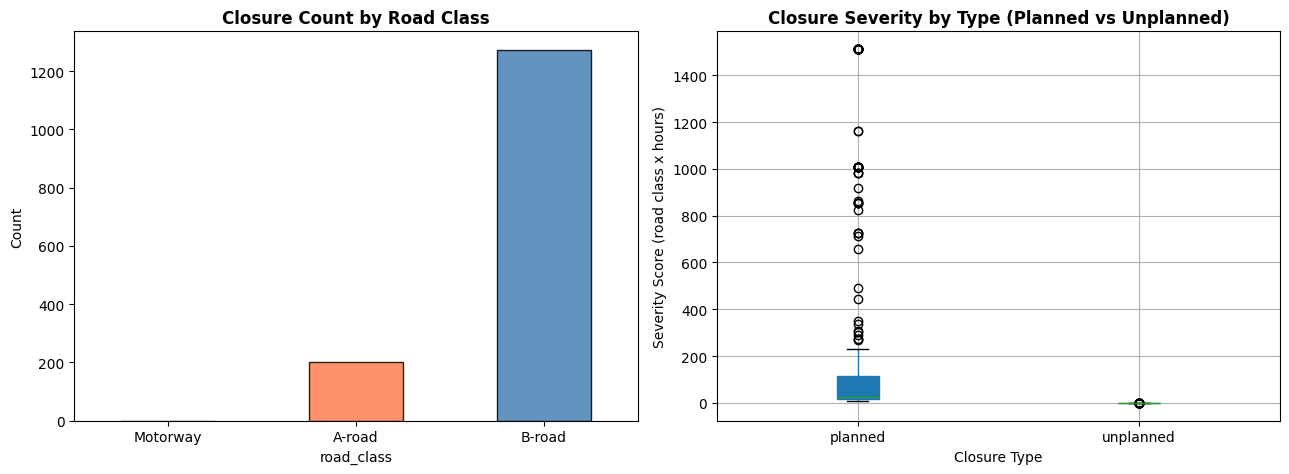

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = road_clean_df["road_class"].value_counts().reindex([1, 2, 3], fill_value=0)

label_map = {1: "Motorway", 2: "A-road", 3: "B-road"}
color_map = {1: "mediumseagreen", 2: "coral", 3: "steelblue"}

counts.plot(
    kind="bar", ax=axes[0],
    color=[color_map[i] for i in counts.index],
    edgecolor="black", alpha=0.85,
)
axes[0].set_xticklabels([label_map[i] for i in counts.index], rotation=0)
axes[0].set_title("Closure Count by Road Class", fontweight="bold")
axes[0].set_ylabel("Count")

road_clean_df.boxplot(column="closure_severity", by="closure_type", ax=axes[1], patch_artist=True)
axes[1].set_title("Closure Severity by Type (Planned vs Unplanned)", fontweight="bold")
axes[1].set_xlabel("Closure Type")
axes[1].set_ylabel("Severity Score (road class x hours)")
plt.suptitle("")

plt.tight_layout()
plt.savefig("figures/eda_02/road_class_severity.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Temporal Distribution

Understanding when closures start and end reveals whether they concentrate in particular hours or days. This informs whether time-of-day features add value beyond closure type and proximity.

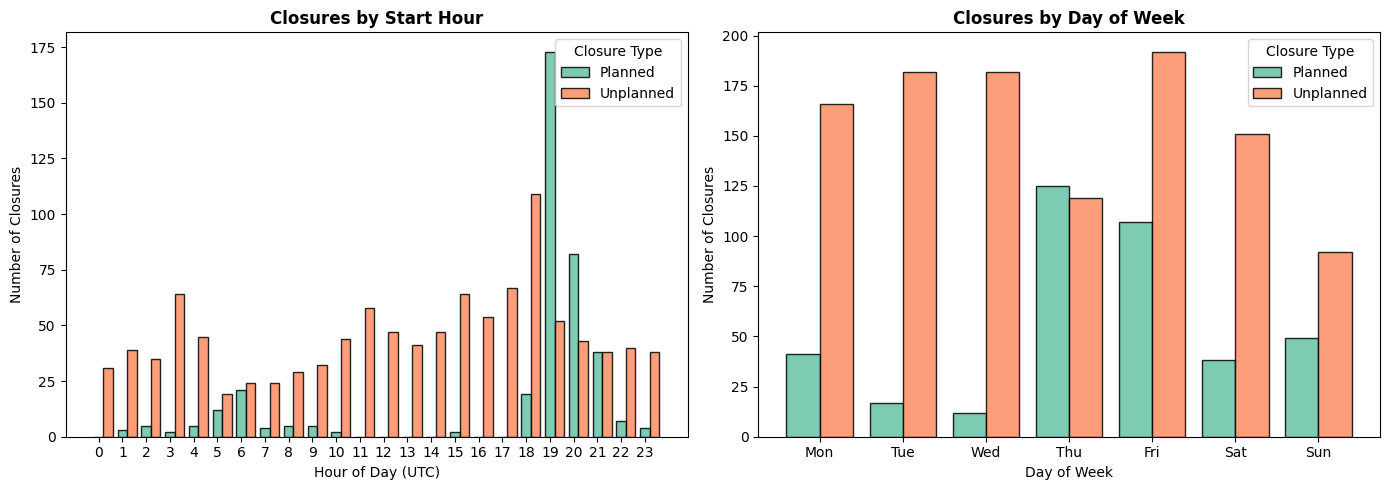

In [21]:
road_clean_df["start_hour"] = road_clean_df["start_time_dt"].dt.hour
road_clean_df["start_dow"]  = road_clean_df["start_time_dt"].dt.dayofweek   # 0=Mon
road_clean_df["start_date"] = road_clean_df["start_time_dt"].dt.date

closure_types = sorted(road_clean_df["closure_type"].unique())
colors = plt.cm.Set2(range(len(closure_types)))
DOW_MAP = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
width = 0.8 / len(closure_types)

# Closures by start hour
x = np.arange(24)
for i, ctype in enumerate(closure_types):
    counts = (
        road_clean_df[road_clean_df["closure_type"] == ctype]["start_hour"]
        .value_counts().reindex(range(24), fill_value=0)
    )
    axes[0].bar(x + i*width, counts.values, width=width,
                label=ctype.capitalize(), color=colors[i],
                edgecolor="black", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(range(24))
axes[0].set_xlabel("Hour of Day (UTC)")
axes[0].set_ylabel("Number of Closures")
axes[0].set_title("Closures by Start Hour", fontweight="bold")
axes[0].legend(title="Closure Type")

# Closures by day of week
x2 = np.arange(7)
for i, ctype in enumerate(closure_types):
    counts = (
        road_clean_df[road_clean_df["closure_type"] == ctype]["start_dow"]
        .value_counts().reindex(range(7), fill_value=0)
    )
    axes[1].bar(x2 + i*width, counts.values, width=width,
                label=ctype.capitalize(), color=colors[i],
                edgecolor="black", alpha=0.85)
axes[1].set_xticks(x2 + width * (len(closure_types) - 1) / 2)
axes[1].set_xticklabels([DOW_MAP[d] for d in range(7)])
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Number of Closures")
axes[1].set_title("Closures by Day of Week", fontweight="bold")
axes[1].legend(title="Closure Type")

plt.tight_layout()
plt.savefig("figures/eda_02/temporal_distribution_by_type.png", dpi=200, bbox_inches="tight")
plt.show()

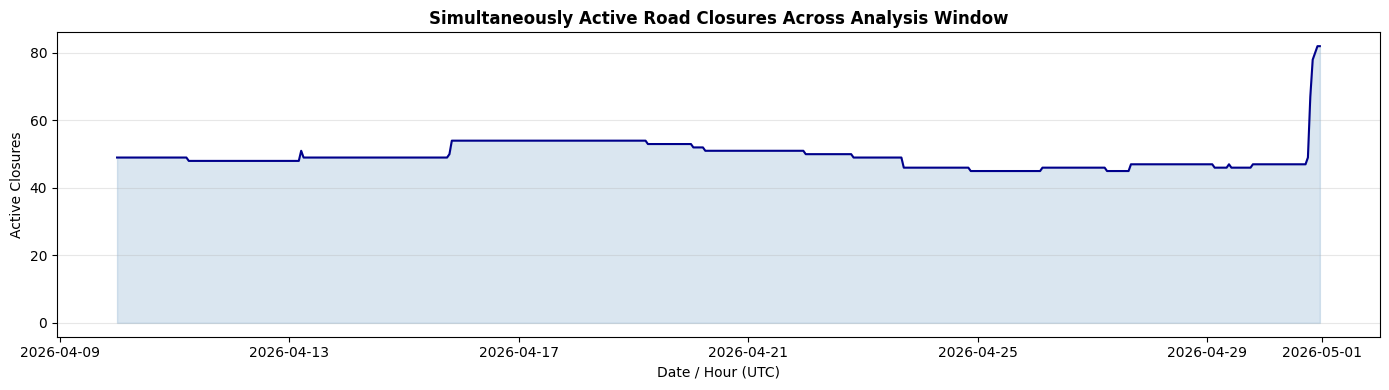

In [22]:
# Count simultaneously active closures at each hour across the analysis window.
hours = pd.date_range(start=START, end=END, freq="h", tz="UTC")

active_counts = [
    (
        (road_clean_df["start_time_dt"] <= h)
        & (road_clean_df["end_time_dt"] >= h)
        & (road_clean_df["validity_status"] == "active")
    ).sum()
    for h in hours
]

plt.figure(figsize=(14, 4))
plt.plot(hours, active_counts, color="darkblue", linewidth=1.5)
plt.fill_between(hours, active_counts, alpha=0.2, color="steelblue")
plt.xlabel("Date / Hour (UTC)")
plt.ylabel("Active Closures")
plt.title("Simultaneously Active Road Closures Across Analysis Window", fontweight="bold")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/eda_02/active_closures_timeline.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Spatial Distribution

Visualising where closures occur reveals geographic concentration and informs whether the 10-25 km distance band captures closures near significant rail corridors.

In [23]:
print("Spatial extent of closures:")
print(f"  Latitude  range: {road_clean_df['closure_lat'].min():.4f} - {road_clean_df['closure_lat'].max():.4f}")
print(f"  Longitude range: {road_clean_df['closure_lon'].min():.4f} - {road_clean_df['closure_lon'].max():.4f}")
print(f"  Missing lat/lon: {road_clean_df['closure_lat'].isna().sum()}")

Spatial extent of closures:
  Latitude  range: 50.2359 - 55.0664
  Longitude range: -5.2584 - 1.7230
  Missing lat/lon: 0


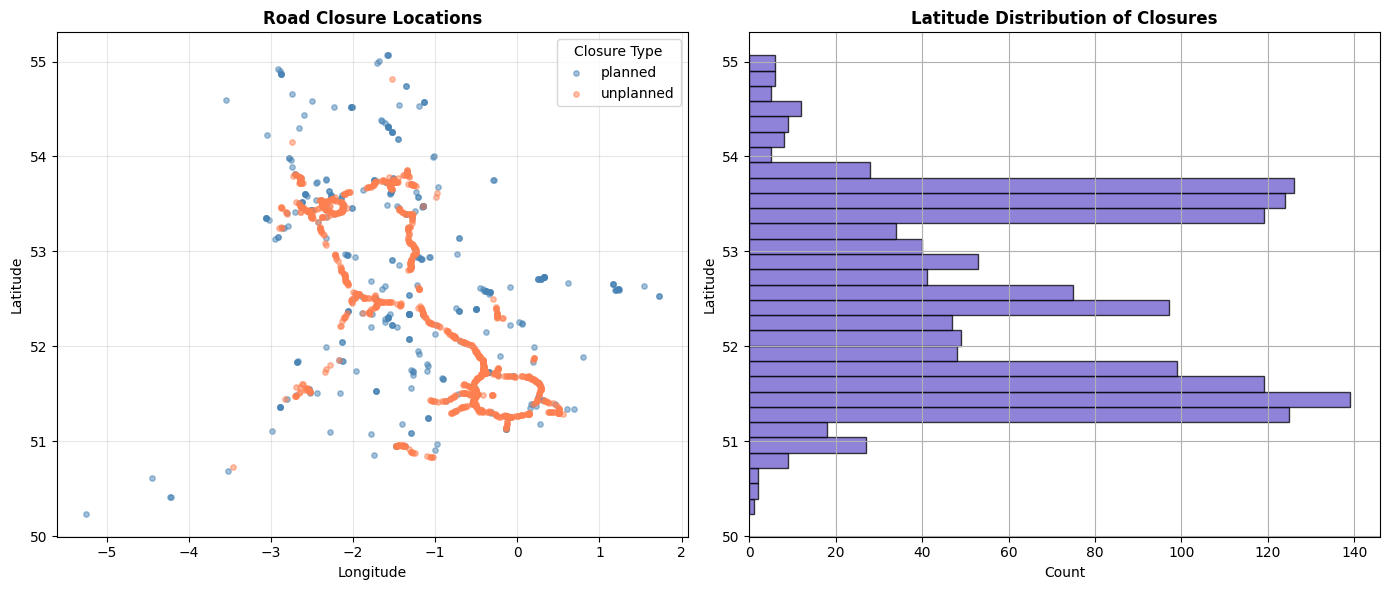

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

color_map = {"planned": "steelblue", "unplanned": "coral"}

for ctype, grp in road_clean_df.groupby("closure_type"):
    axes[0].scatter(grp["closure_lon"], grp["closure_lat"],
                    alpha=0.5, s=15, label=ctype, color=color_map.get(ctype, "grey"))

axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Road Closure Locations", fontweight="bold")
axes[0].legend(title="Closure Type")
axes[0].grid(alpha=0.3)

# Density: latitude histogram
road_clean_df["closure_lat"].hist(bins=30, ax=axes[1], color="slateblue",
                             edgecolor="black", alpha=0.75, orientation="horizontal")
axes[1].set_ylabel("Latitude")
axes[1].set_xlabel("Count")
axes[1].set_title("Latitude Distribution of Closures", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_02/spatial_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

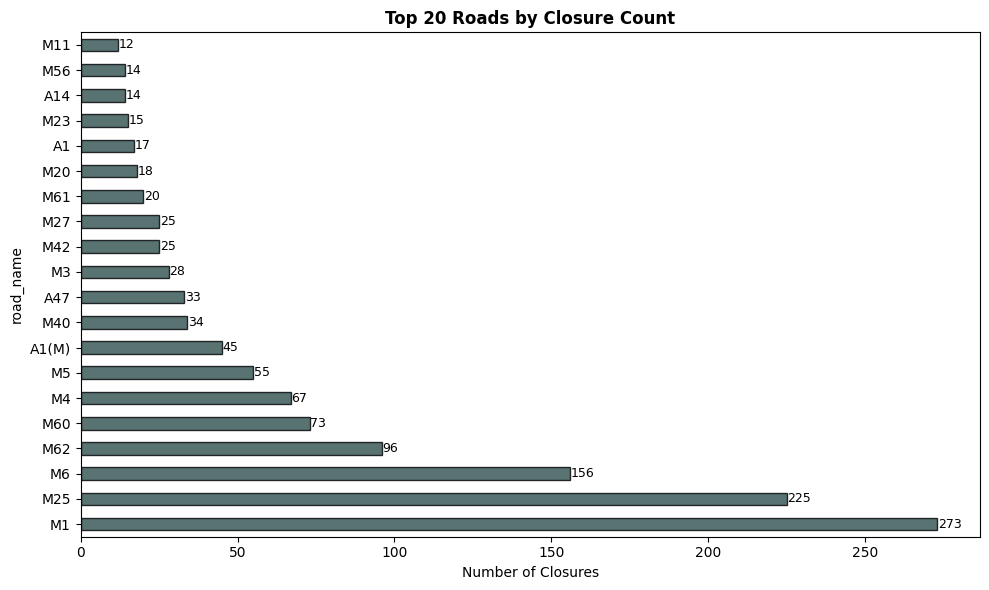

In [25]:
# Road name frequency: which roads have the most closures?
if "road_name" in road_clean_df.columns:
    road_counts = road_clean_df["road_name"].value_counts().head(20)
    plt.figure(figsize=(10, 6))
    road_counts.plot(kind="barh", color="darkslategray", edgecolor="black", alpha=0.8)
    plt.xlabel("Number of Closures")
    plt.title("Top 20 Roads by Closure Count", fontweight="bold")
    for i, v in enumerate(road_counts.values):
        plt.text(v + 0.2, i, str(v), va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_02/top_roads.png", dpi=200, bbox_inches="tight")
    plt.show()

## 10. Lanes Closed Distribution

The number of lanes closed provides a proxy for disruption severity. A single-lane closure on a dual carriageway is far less disruptive than a full road closure.

In [26]:
if "lanes_closed" in road_clean_df.columns:
    lanes = road_clean_df["lanes_closed"].dropna()
    print("Lanes closed statistics:")
    print(lanes.describe().round(2))
    print()
    print(lanes.value_counts().sort_index().to_string())

Lanes closed statistics:
count    1473.00
mean        0.42
std         0.89
min         0.00
25%         0.00
50%         0.00
75%         0.00
max         5.00
Name: lanes_closed, dtype: float64

lanes_closed
0    1129
1     166
2     114
3      38
4      22
5       4


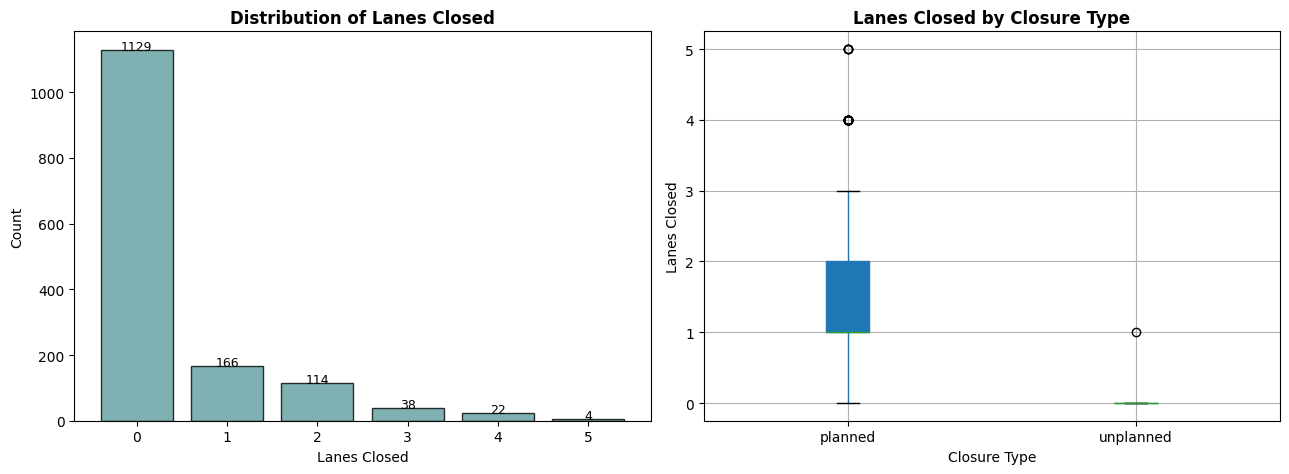

In [27]:
if "lanes_closed" in road_clean_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    lc_counts = road_clean_df["lanes_closed"].value_counts().sort_index()
    axes[0].bar(lc_counts.index.astype(str), lc_counts.values,
                color="cadetblue", edgecolor="black", alpha=0.8)
    axes[0].set_xlabel("Lanes Closed")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Distribution of Lanes Closed", fontweight="bold")
    for i, v in enumerate(lc_counts.values):
        axes[0].text(i, v + 0.3, str(v), ha="center", fontsize=9)

    road_clean_df.boxplot(column="lanes_closed", by="closure_type", ax=axes[1],
                    patch_artist=True)
    axes[1].set_title("Lanes Closed by Closure Type", fontweight="bold")
    axes[1].set_xlabel("Closure Type")
    axes[1].set_ylabel("Lanes Closed")
    plt.suptitle("")

    plt.tight_layout()
    plt.savefig("figures/eda_02/lanes_closed.png", dpi=200, bbox_inches="tight")
    plt.show()

## 11. Summary and Saved Output Check

The parquet file is saved again after adding the new features introduced in the above sections.

In [28]:
# Final cleaned dataset columns and dtypes
road_clean_df.to_parquet("./data/processed/road_closures_clean.parquet", index=False)
road_clean_df.query("closure_type == 'unplanned'").to_parquet("./data/processed/unplanned_road_closures.parquet", index=False)
road_clean_df.query("closure_type == 'planned'").to_parquet("./data/processed/planned_road_closures.parquet", index=False)

road_clean_df.to_csv("./sample_data/processed/road_closures_clean.csv", index=False)

In [29]:
print("Final cleaned dataset columns and dtypes:")
display(road_clean_df.info())
road_clean_df.columns

Final cleaned dataset columns and dtypes:
<class 'pandas.DataFrame'>
Index: 1473 entries, 0 to 1775
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   situation_id              1473 non-null   string             
 1   record_id                 1473 non-null   string             
 2   start_time                1473 non-null   str                
 3   end_time                  1473 non-null   str                
 4   validity_status           1473 non-null   str                
 5   cause_type                1473 non-null   str                
 6   source                    1473 non-null   str                
 7   road_name                 1473 non-null   str                
 8   lanes_closed              1473 non-null   int64              
 9   closure_lat               1473 non-null   float64            
 10  closure_lon               1473 non-null   float64         

None

Index(['situation_id', 'record_id', 'start_time', 'end_time',
       'validity_status', 'cause_type', 'source', 'road_name', 'lanes_closed',
       'closure_lat', 'closure_lon', 'poslist', 'ingestion_time',
       'closure_type', 'start_time_dt', 'end_time_dt', 'duration_hours',
       'effective_start_time', 'effective_end_time',
       'effective_duration_hours', 'road_class', 'closure_severity',
       'start_hour', 'start_dow', 'start_date'],
      dtype='str')